# import libraries

In [241]:
import matplotlib.pyplot as plt
import numpy as np

\section*{One-Line Agenda: Signal Transformations}

If a generator function is given, any kind of time transformation 
can be achieved with a single line of code.

For example, if the base function ${sine\_signal(t)}$ is given:
$$ \text{sine\_signal}(t) = \sin(t) $$

And you need to generate the transformed signal $y$:
$$ y = \sin\left(-t + \frac{\pi}{2}\right) $$

You can achieve this transformation in just one line of code:

$$ y = sine\_signal(-t + π / 2) $$


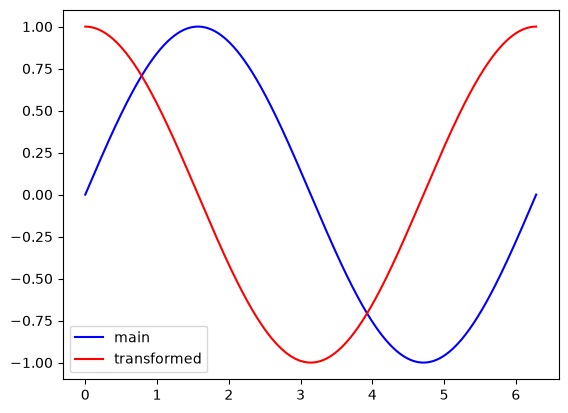

In [242]:
# code explanation

def sine_signal(t):
    x = np.sin(t)
    return x

def main():
    t = np.linspace(0,np.pi * 2, 1000)
    x = sine_signal(t)
    y = sine_signal(-t + np.pi / 2)

    plt.plot(t,x, color='blue', label = 'main')
    plt.plot(t,y, color='red', label = 'transformed')

    plt.legend()
    plt.show()
main()

# shift signal [full]

In [243]:
def shift_signal(x,t,beta):
    dt = t[1] - t[0]
    shift_by = round(beta/dt)

    y = np.roll(x, shift_by)

    return y

# shift signal [limitted] ***

In [244]:

def shift_signal2(x,t,beta):
    dt = t[1] - t[0]
    shift_by = round(beta/dt)

    y = np.roll(x, shift_by)

    if(shift_by > 0):
            y[:shift_by] = 0
    elif(shift_by < 0):
        y[shift_by:] = 0
        
    return y

# reverse signal

## general idea

In [245]:
def reverse_signal2(x, t):
    dt = t[1] - t[0]
    t0 = t[0]
    n = len(t)
    y = np.zeros(n)

    for i in range(n):
        target_time = -t[i]                       # the time we actually want
        index_float = (target_time - t0) / dt     # convert to array position

        if 0 <= index_float <= n - 1:
            y[i] = x[round(index_float)]
        else:
            y[i] = 0   # target time falls outside sampled domain

    return y

## for symmetric functions

In [246]:
def reverse_signal(x,t):
    y = x[::-1]

    return y

## only works with periodic function when the domain is the period of the function

for example, $y = \sin(t)$ for $t \in [0, 2\pi]$

period of $\sin(t)$ = $2\pi$

domain given = $2\pi$

so for this, if the following reverse function (array manipulation) is used then the

reversal will be performed perfectly. otherwise, for example

$y = \sin(t)$ for $t \in [0, 3\pi]$     <--- it won't work

$y = x^2 + 3x$                          <--- it won't work


# amplitude scale signal

In [247]:
def amp_scale_signal(x,t,alpha):
    y = alpha * x

    return y

# time scale signal [full]
when multiplied, the signal shrinks.    y(t) = sin(5t)  -> high frequency

when divided, the signal expands.       y(t) = sin(t/2) -> low frequency

In [248]:
def scale_signal(x, t, alpha):
    dt = t[1] - t[0]
    n = len(t)
    y = np.zeros(n)

    for i in range(n):
        target_time = alpha * t[i]
        index = round(target_time / dt)
        index = index % n   # wrap instead of going out of bounds

        y[i] = x[index]

    return y

# time scale signal [limitted] ***

In [249]:
def scale_signal2(x, t, alpha):
    dt = t[1] - t[0]
    n = len(t)
    y = np.zeros(n)

    for i in range(n):
        # We want y[i] = x(alpha * t[i])
        # Find which index in t corresponds to time alpha*t[i]
        target_time = alpha * t[i]
        index = round(target_time / dt)

        if 0 <= index < n:
            y[i] = x[index]
        else:
            y[i] = 0  # out of range, pad with 0

    return y

# sine wave

In [250]:
def sine_signal(t):
    x = np.sin(t)
    return x

## -π to π sine wave 

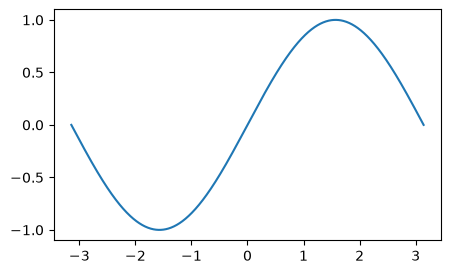

In [251]:
def plot_sine():
    t = np.linspace(-np.pi, np.pi, 1000)
    x = sine_signal(t)

    plt.figure(figsize = (5,3))
    plt.plot(t,x)



    plt.show()

plot_sine()


## formatted

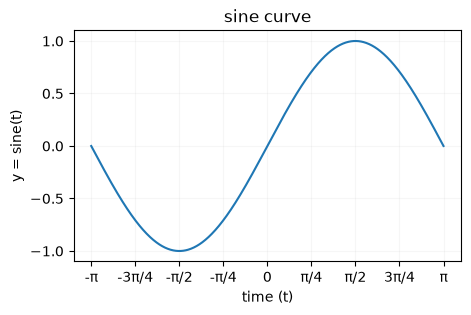

In [252]:
def plot_sine2():
    t = np.linspace(-np.pi, np.pi, 1000)
    x = sine_signal(t)

    plt.figure(figsize = (5,3))
    plt.plot(t,x)

    ticks = np.linspace(-np.pi, np.pi, 9)
    labels = ['-π', '-3π/4', '-π/2','-π/4', '0', 'π/4', 'π/2', '3π/4', 'π']
    plt.xticks(ticks, labels)

    plt.grid(True, alpha = 0.1)
    plt.xlabel('time (t)')
    plt.ylabel('y = sine(t)')
    plt.title('sine curve')

    plt.show()

plot_sine2()

## left shift sine signal by π/2 (full signal)
## $$ sin(t + π/2) $$

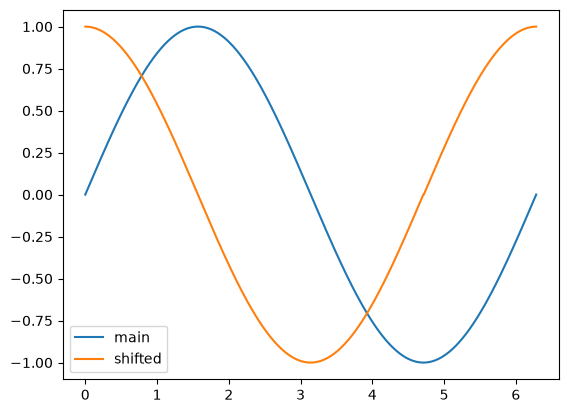

In [253]:
def main1():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = np.pi / 2

    x_shifted = shift_signal(x,t,-alpha)
    y = x_shifted

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main1()

## left shift sine signal by π/2 (limitted signal)
## $$ sin(t + π/2) $$

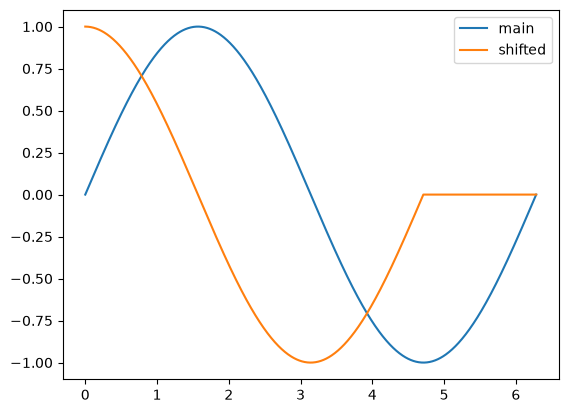

In [254]:
def main1():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = np.pi / 2

    x_shifted = shift_signal2(x,t,-alpha)  # <--- change 
    y = x_shifted

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main1()

## practice

### y = 2sin(t - π/2)

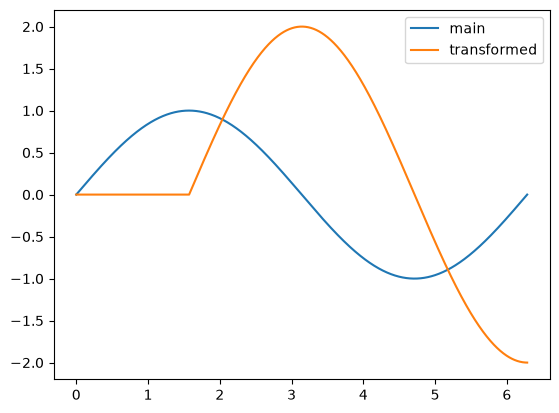

In [261]:
def main2():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = -np.pi / 2

    x_shifted = shift_signal2(x,t, -alpha)
    y = amp_scale_signal(x_shifted,t,2)

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'transformed')

    plt.legend()
    plt.show()


main2()

### y = 2sin(5t - π/2)

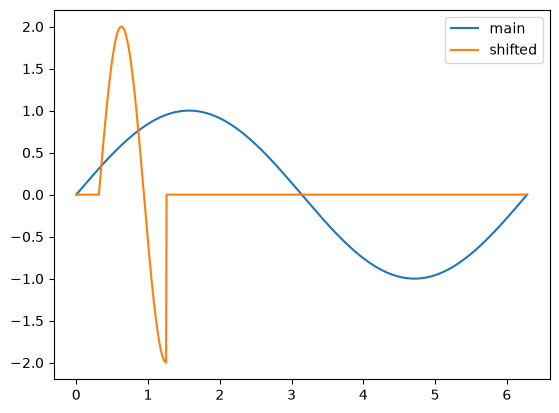

In [262]:
def main3():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = -np.pi / 2

    x_shifted = shift_signal2(x,t, -alpha)
    x_scaled = scale_signal2(x_shifted,t,5)
    y = amp_scale_signal(x_scaled,t,2)


    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main3()

# find even odd parts of x(t)

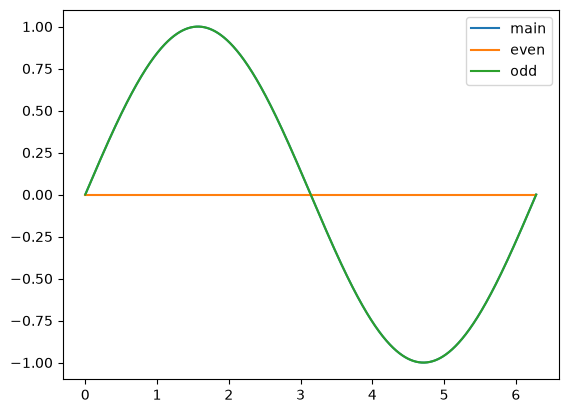

In [ ]:
def main3():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)

    # x_even = 1/2 ( x(t) + x(-t) )

    x_rev = reverse_signal(x,t)
    x_sum = x + x_rev
    x_even = amp_scale_signal(x_sum, t, 0.5)

    # x_odd = 1/2 ( x(t) - x(-t) )
    x_sub = x - x_rev
    x_odd = amp_scale_signal(x_sub, t, 0.5)
    

    plt.plot(t,x, label = 'main')
    plt.plot(t,x_even, label = 'even')
    plt.plot(t,x_odd, label = 'odd')

    plt.legend()
    plt.show()


main3()

# poly signal

## generate poly signal 1 : y = x^3 + 3x

In [258]:
def poly_signal(t):
    y = t**3 + 3*t
    
    return y

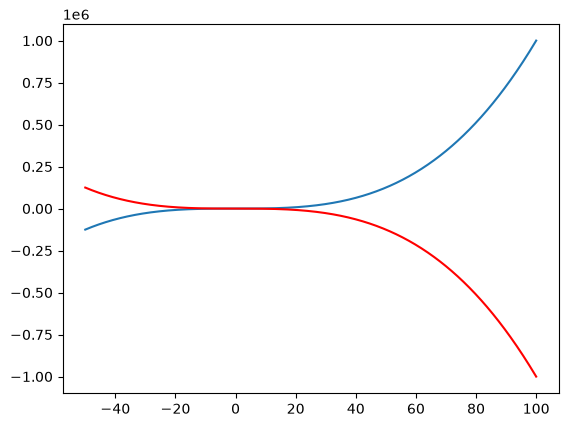

In [259]:
def main4():
    t = np.linspace(-50,100,1000)
    x = poly_signal(t)
    y = poly_signal(-t)

    plt.plot(t,x)
    plt.plot(t,y,color='red')
    plt.show()

main4()

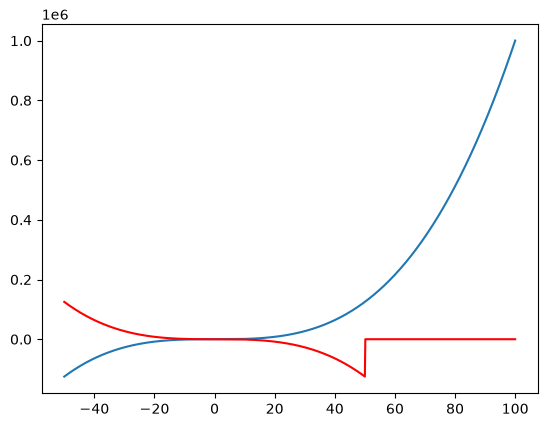

In [260]:
def main4():
    t = np.linspace(-50,100,1000)
    x = poly_signal(t)
    y = reverse_signal2(x,t)

    plt.plot(t,x)
    plt.plot(t,y,color='red')
    plt.show()

main4()

### why the graph looks wrong but is correct. explanation:

for x(t) the domain is -50 to 100

but, for (t) the domain is -100 to 50

which eventually is -50 to 50

cause, we have the value moved using array manipulation and they rotated.

so, we don't have value for outside this